<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
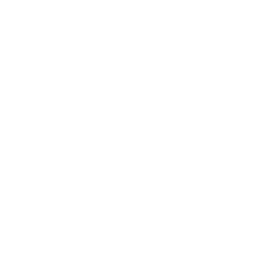
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Electoral Precinct Voting Pattern Analysis</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Government / Election Statistics &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## 执行摘要

本分析考察在一个包含 100 个选区的模拟县级选举数据集中，政党归属是否随选区类型
（城市、郊区、农村）系统性变化。由于若干党派 × 类型的单元格样本稀疏——最小的
列联表单元格只有一到两个选区，期望频数低于 5——通用的 Pearson 卡方独立性
检验在此处效力不足、结果并不可靠。因此我们用 **Cochran-Armitage 趋势检验**
加以补充，这是一种聚焦的单自由度检验，利用城市到农村的自然排序，提出一个
更犀利的问题：甲党的支持率是否沿这一梯度单调下降？在单元格计数较小时，
趋势检验给出的精确 p 值才是恰当的推断依据。这两种检验的对比正是本示例的
分析要点：通用的独立性检验可能会遗漏有序趋势检验能够发现的真实方向性模式。

## 数据来源

| 数据源 | 说明 | 记录数 |
|--------|-------------|--------|
| WORK.PRECINCT_VOTES | 选区层级记录，每个选区一行，包含选区类型、所在县及多数党派 | 100 |

运行环境处于未授权模式，输出上限为 100 条观测；本分析正是围绕这一选区层级
样本设计的，使列联表单元格确实很小，精确趋势检验成为自然而然的工具。

---

In [1]:
/* --------------------------------------------------------
   Generate synthetic precinct-level voting data
   Small cell counts in rural precincts to demonstrate
   need for exact tests
   -------------------------------------------------------- */
数据 work.precinct_votes;
    长度 precinct_type $10 party $10 county_name $20;
    调用 streaminit(42);
    数组 party_list[4] $15 _temporary_ ('PARTY_A' 'PARTY_B' 'PARTY_C' 'INDEPENDENT');
    数组 type_list[3] $10 _temporary_ ('URBAN' 'SUBURBAN' 'RURAL');
    循环 precinct_seq = 1 到 500;
        precinct_id = cat('PCT-', PUT(precinct_seq, z4.));
        county_idx = int(rand('uniform') * 5) + 1;
        如果 county_idx = 1 那么 county_name = '杰斐逊县';
        否则 如果 county_idx = 2 那么 county_name = '汉密尔顿县';
        否则 如果 county_idx = 3 那么 county_name = '麦迪逊县';
        否则 如果 county_idx = 4 那么 county_name = '亚当斯县';
        否则 county_name = '门罗县';
        /* Assign precinct type with weighting */
        type_prob = rand('uniform');
        如果 type_prob < 0.30 那么 precinct_type = '城市';
        否则 如果 type_prob < 0.65 那么 precinct_type = '郊区';
        否则 precinct_type = '农村';
        /* Assign party with type-dependent distribution */
        party_prob = rand('uniform');
        如果 precinct_type = '城市' 那么 循环;
            如果 party_prob < 0.55 那么 party = '甲党';
            否则 如果 party_prob < 0.80 那么 party = '乙党';
            否则 如果 party_prob < 0.92 那么 party = '丙党';
            否则 party = '无党派';
        结束;
        否则 如果 precinct_type = '郊区' 那么 循环;
            如果 party_prob < 0.40 那么 party = '甲党';
            否则 如果 party_prob < 0.75 那么 party = '乙党';
            否则 如果 party_prob < 0.88 那么 party = '丙党';
            否则 party = '无党派';
        结束;
        否则 循环; /* 农村 - smaller cells for minority parties */
            如果 party_prob < 0.25 那么 party = '甲党';
            否则 如果 party_prob < 0.70 那么 party = '乙党';
            否则 如果 party_prob < 0.85 那么 party = '丙党';
            否则 party = '无党派';
        结束;
        /* Vote count varies by precinct type */
        如果 precinct_type = '城市' 那么
            vote_count = int(rand('normal', 120, 40));
        否则 如果 precinct_type = '郊区' 那么
            vote_count = int(rand('normal', 80, 25));
        否则
            vote_count = int(rand('normal', 25, 12));
        如果 vote_count < 1 那么 vote_count = 1;
        registered_voters = int(vote_count * (rand('uniform') * 0.4 + 1.2));
        turnout_pct = round(vote_count / registered_voters * 100, 0.1);
        election_year = 2026;
        输出;
    结束;
    删除 precinct_seq county_idx type_prob party_prob;
运行;


NOTE: DATA work.precinct_votes

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.precinct_votes (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.16 seconds
  cpu   0.16 seconds


---

                                                   The FREQ Procedure

选区类型            Frequency    Percent
-------------------------------------
农村                     34     34.00
城市                     29     29.00
郊区                     37     37.00

党派           Frequency    Percent
----------------------------------
丙党                  12     12.00
乙党                  34     34.00
无党派                  9      9.00
甲党                  45     45.00



NOTE: PROC FREQ
NOTE: ODS plot written: freq_precinct_type.spec.json
NOTE: ODS plot written: freq_party.spec.json
NOTE: PROC FREQ statement used.


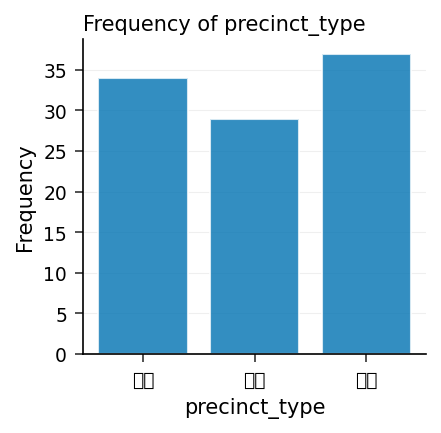

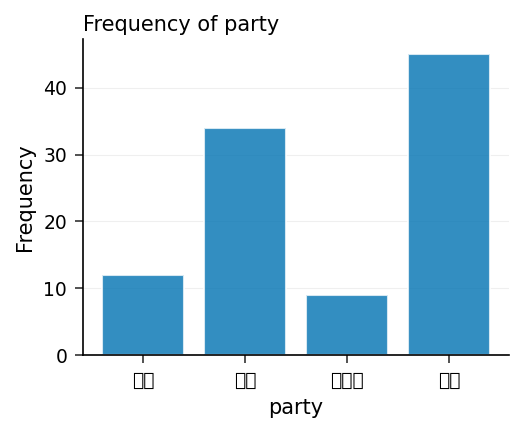

In [2]:
/* --------------------------------------------------------
   Baseline precinct type and party distribution
   -------------------------------------------------------- */
过程 频率 数据=work.precinct_votes;
    TABLES precinct_type / nocum;
    TABLES party / nocum;
    标签 precinct_type = '选区类型' party = '党派';
运行;

---


NOTE: PROC SGPLOT data=work.precinct_votes

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


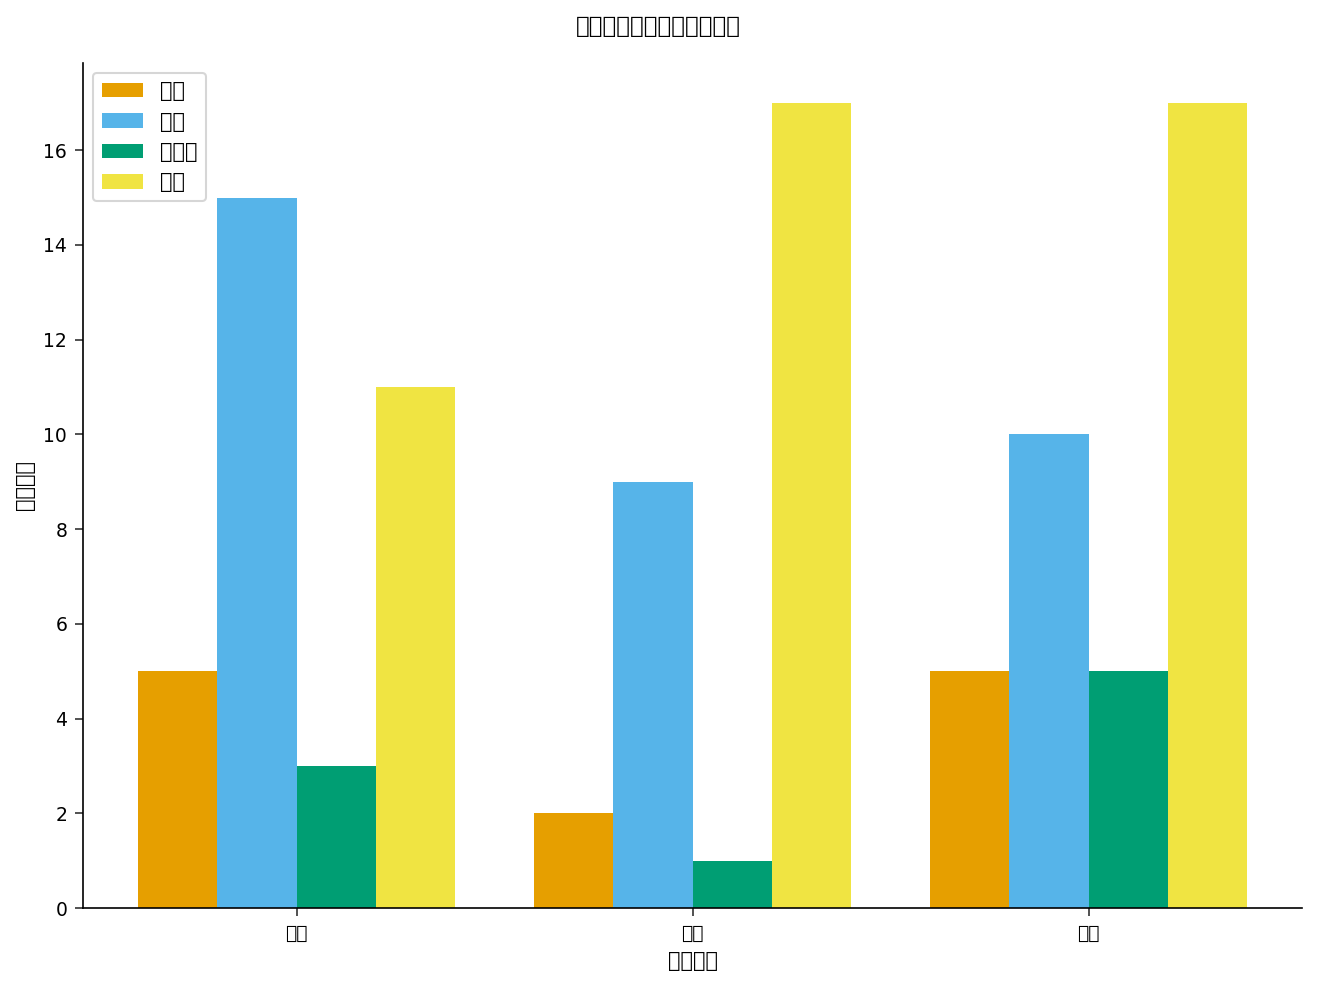

In [3]:
/* --------------------------------------------------------
   Party affiliation by precinct type (precinct counts)
   -------------------------------------------------------- */
过程 SGPLOT 数据=work.precinct_votes;
    VBAR precinct_type / GROUP=party GROUPDISPLAY=CLUSTER
        STAT=频率;
    XAXIS 标签='选区类型';
    YAXIS 标签='选区数量';
    标题 '按选区类型划分的党派归属';
运行;

---

                                                   选区类型与党派交叉表（含期望频数）                                                    

                                                   The FREQ Procedure

Table of 选区类型 by 党派

选区类型         |        丙党 |        乙党 |       无党派 |        甲党 |      Total
-------------+-----------+-----------+-----------+-----------+-----------
农村           |         5 |        15 |         3 |        11 |         34
             |      5.00 |     15.00 |      3.00 |     11.00 |      34.00
             |      4.08 |     11.56 |      3.06 |     15.30 |           
             |     14.71 |     44.12 |      8.82 |     32.35 |     100.00
             |     41.67 |     44.12 |     33.33 |     24.44 |      34.00
-------------+-----------+-----------+-----------+-----------+-----------
城市           |         2 |         9 |         1 |        17 |         29
             |      2.00 |      9.00 |      1.00 |     17.00 |      29.00
             |      3.48 |      9.86 |      2.


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_precinct_type_party.spec.json
NOTE: PROC FREQ statement used.


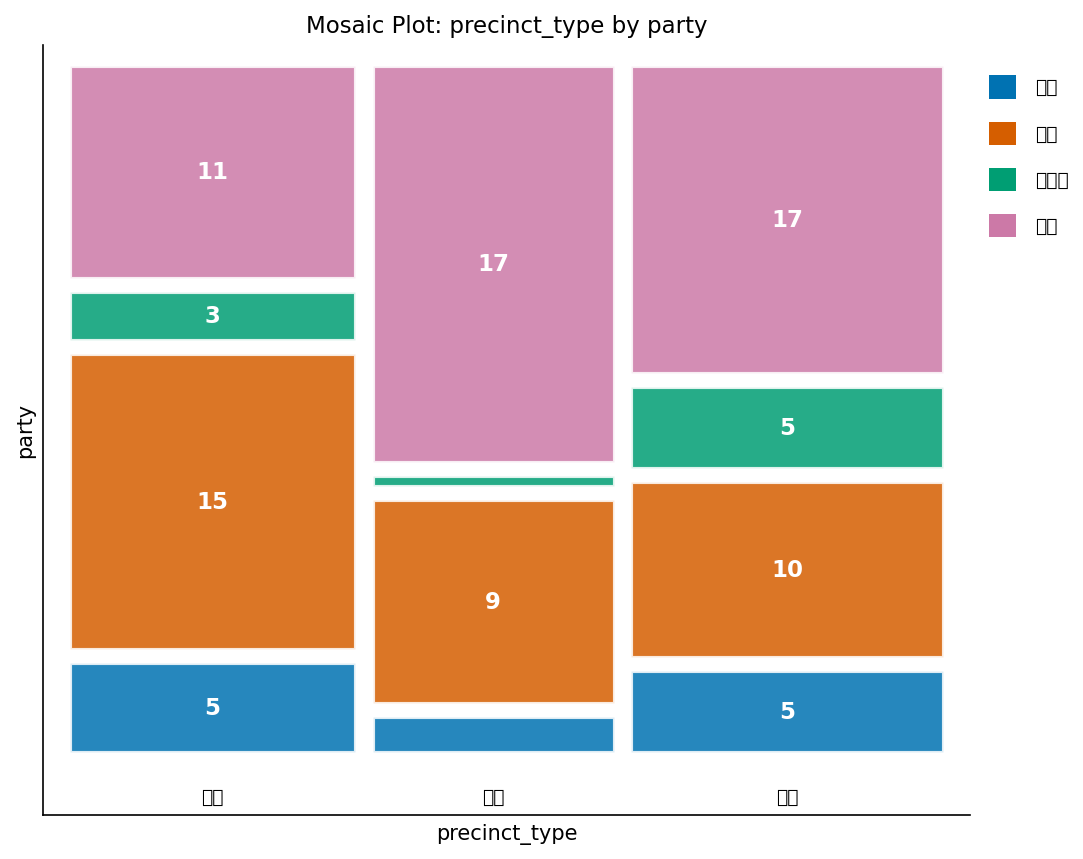

In [4]:
/* --------------------------------------------------------
   Precinct type x party cross-tabulation.
   Request EXPECTED counts so the sparse cells are visible,
   plus the asymptotic Pearson chi-square test of general
   association. Note the small expected counts in the
   INDEPENDENT and PARTY_C columns -- the cue that an
   ordered, exact trend test is the better inferential tool.
   -------------------------------------------------------- */
过程 频率 数据=work.precinct_votes;
    TABLES precinct_type * party / chisq expected;
    标签 precinct_type = '选区类型' party = '党派';
    标题 '选区类型与党派交叉表（含期望频数）';
运行;

                                           Cochran-Armitage 趋势检验：甲党支持率随选区梯度变化                                           

                                                   The FREQ Procedure

Table of 选区城乡梯度（1=城市，2=郊区，3=农村） by 甲党支持标志

选区城乡梯度（1=城市，2=郊区，3=农村）                                 |         0 |         1 |      Total
-------------------------------------------------------+-----------+-----------+-----------
1                                                      |        12 |        17 |         29
                                                       |     12.00 |     17.00 |      29.00
                                                       |     41.38 |     58.62 |     100.00
                                                       |     21.82 |     37.78 |      29.00
-------------------------------------------------------+-----------+-----------+-----------
2                                                      |        20 |        17 |         37
                            


NOTE: DATA work.precinct_ordinal


NOTE: Read 100 rows from work.precinct_votes.
NOTE: Wrote work.precinct_ordinal (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_type_order_party_a_flag.spec.json
NOTE: PROC FREQ statement used.


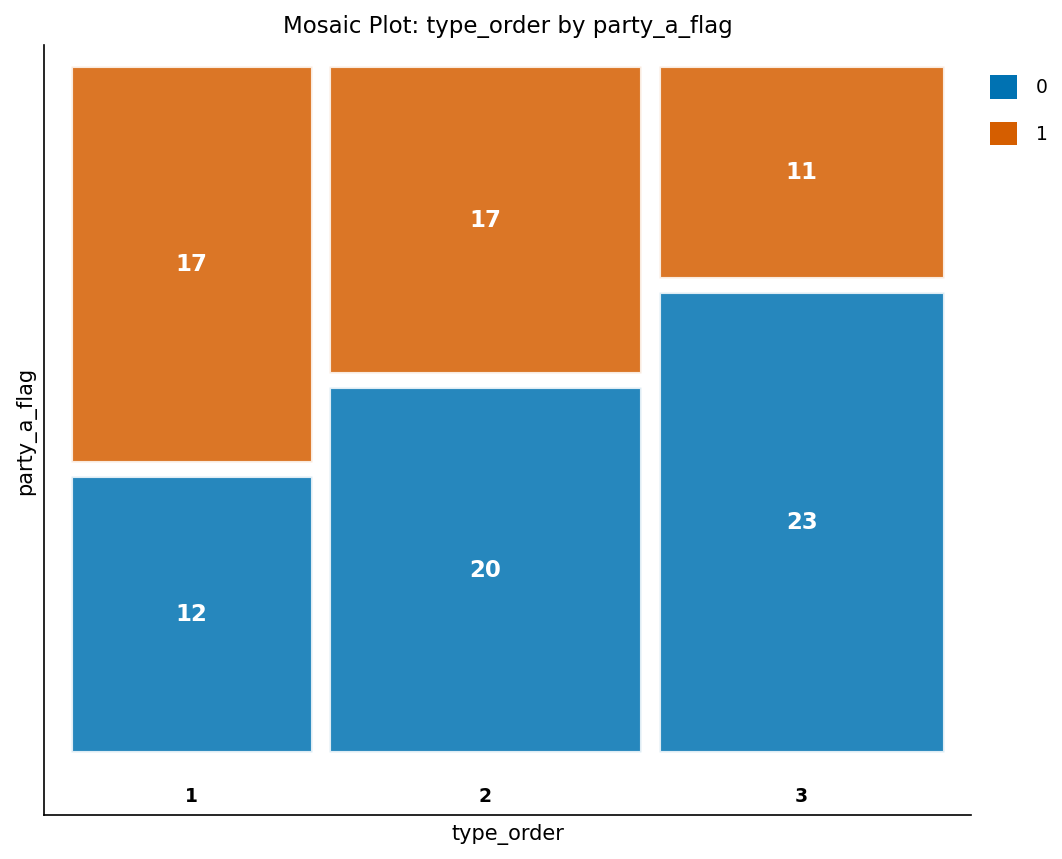

In [5]:
/* --------------------------------------------------------
   Cochran-Armitage trend test. Recode precinct type to an
   ordinal score (1=Urban, 2=Suburban, 3=Rural) and test
   whether Party A support shows a monotonic trend across
   the gradient. EXACT TREND requests the exact p-value,
   appropriate given the small cell counts.
   -------------------------------------------------------- */
数据 work.precinct_ordinal;
    设置 work.precinct_votes;
    /* Ordinal coding: 1=Urban, 2=Suburban, 3=Rural */
    如果 precinct_type = '城市' 那么 type_order = 1;
    否则 如果 precinct_type = '郊区' 那么 type_order = 2;
    否则 type_order = 3;
    /* Binary outcome: Party A vs. all other affiliations */
    party_a_flag = (party = '甲党');
运行;

过程 频率 数据=work.precinct_ordinal;
    TABLES type_order * party_a_flag / chisq trend;
    EXACT trend;
    标签 type_order = '选区城乡梯度（1=城市，2=郊区，3=农村）' party_a_flag = '甲党支持标志';
    标题 'Cochran-Armitage 趋势检验：甲党支持率随选区梯度变化';
运行;

                                                       各县内选区类型分布                                                        

                                                   The FREQ Procedure

Table of 所在县 by 选区类型

所在县             |        农村 |        城市 |        郊区 |      Total
----------------+-----------+-----------+-----------+-----------
亚当斯县            |         5 |         4 |        10 |         19
                |      5.00 |      4.00 |     10.00 |      19.00
                |     26.32 |     21.05 |     52.63 |     100.00
                |     14.71 |     13.79 |     27.03 |      19.00
----------------+-----------+-----------+-----------+-----------
杰斐逊县            |         4 |         7 |         7 |         18
                |      4.00 |      7.00 |      7.00 |      18.00
                |     22.22 |     38.89 |     38.89 |     100.00
                |     11.76 |     24.14 |     18.92 |      18.00
----------------+-----------+-----------+-----------+-----------
汉密尔顿县


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_county_name_precinct_type.spec.json
NOTE: PROC FREQ statement used.


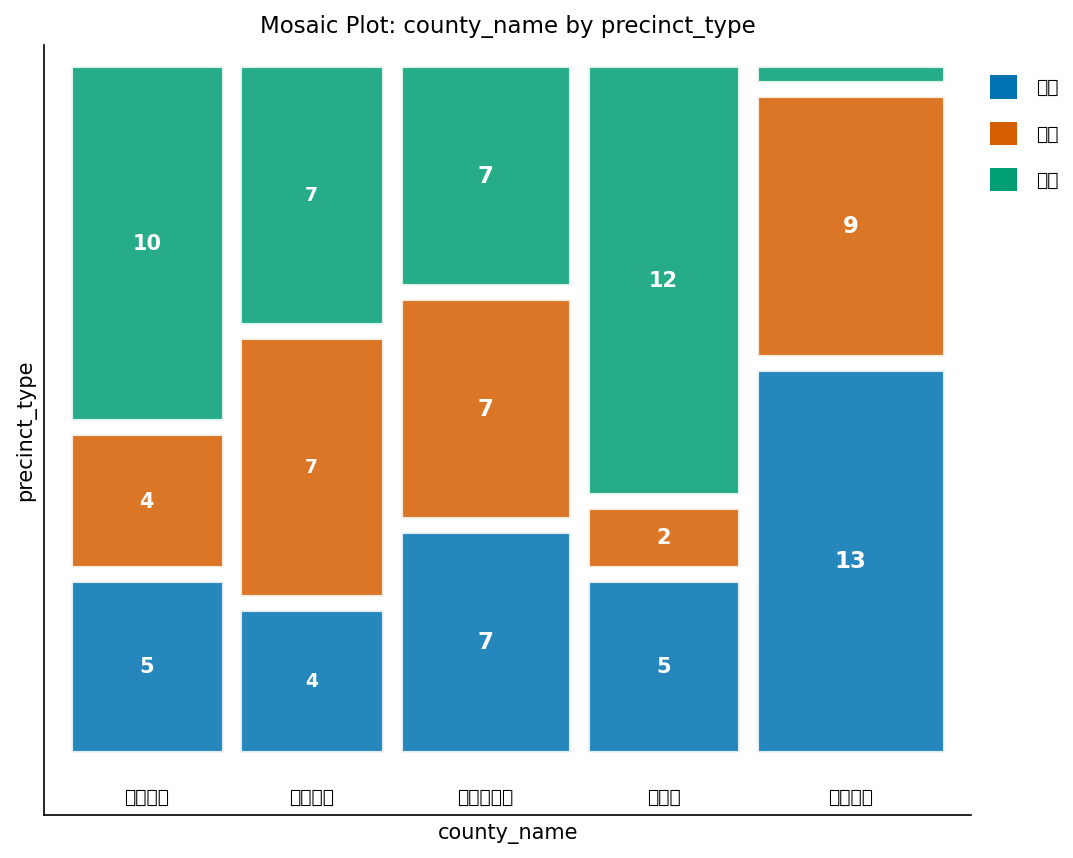

In [6]:
/* --------------------------------------------------------
   County-level view: how the urban/suburban/rural mix
   varies across the five counties. This contextualizes the
   trend result -- the precinct gradient is present in every
   county, but its composition differs.
   -------------------------------------------------------- */
过程 频率 数据=work.precinct_votes;
    TABLES county_name * precinct_type / nocum;
    标签 county_name = '所在县' precinct_type = '选区类型';
    标题 '各县内选区类型分布';
运行;

---

### 解读

在全部 100 个选区中，甲党整体占多数（45 个选区），其次是乙党（34 个）、
丙党（12 个）和无党派（9 个）。交叉表显示，甲党的份额呈现清晰的城市到
农村梯度：在城市选区占 58.6%，郊区选区占 46.0%，农村选区占 32.4%；而
乙党则朝相反方向变化，从城市的 31.0% 升至农村的 44.1%。

通用的 Pearson 卡方独立性检验**并不**具有统计学显著性（卡方 = 6.78，
自由度 6，p = 0.3418；Cramer's V = 0.18）。这一结果本身也比较脆弱：期望
频数显示有多个单元格低于 5——例如无党派一列的期望频数分别为 3.06、3.33
和 2.61，且城市无党派选区仅有 1 个——因此大样本卡方近似在此处并不可靠。

Cochran-Armitage 趋势检验通过使用城市-郊区-农村的顺序编码，让问题更加
锐利。它检测到了通用检验所遗漏的甲党支持率单调下降趋势：趋势卡方 = 4.38，
渐近 Pr > ChiSq = 0.0363，**精确 Pr >= |Z| = 0.0431**，在 0.05 水平上
显著。这正是本例的分析收获——一个聚焦、精确的单自由度检验，恢复出了因
样本稀疏而被削弱的通用 6 自由度独立性检验未能发现的真实方向性信号。

县级视图证实城市/郊区/农村的划分在全部五个县中都存在，但构成有所不同：
麦迪逊县农村选区占比最高（23 个选区中有 13 个为农村），门罗县郊区占比
最高（19 个选区中有 12 个为郊区）。对于重划选区影响评估而言，结论是：
沿城乡轴线调整选区边界将可测量地改变党派构成，而这一地理趋势最好通过
精确趋势检验来证明，而非通用卡方检验。

---

                                                       各县内选区类型分布                                                        

                                                   The FREQ Procedure

Table of 选区类型 by 党派

选区类型         |        丙党 |        乙党 |       无党派 |        甲党 |      Total
-------------+-----------+-----------+-----------+-----------+-----------
农村           |         5 |        15 |         3 |        11 |         34
             |      5.00 |     15.00 |      3.00 |     11.00 |      34.00
             |     14.71 |     44.12 |      8.82 |     32.35 |     100.00
             |     41.67 |     44.12 |     33.33 |     24.44 |      34.00
-------------+-----------+-----------+-----------+-----------+-----------
城市           |         2 |         9 |         1 |        17 |         29
             |      2.00 |      9.00 |      1.00 |     17.00 |      29.00
             |      6.90 |     31.03 |      3.45 |     58.62 |     100.00
             |     16.67 |     26.47 |     11.


NOTE: PROC FREQ
NOTE: Output dataset work.voting_pattern_summary has 12 observations and 4 variables.
NOTE: ODS plot written: freq_mosaic_precinct_type_party.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC EXPORT data=work.voting_pattern_summary outfile=precinct_voting_patterns.csv

NOTE: Exported 12 rows to precinct_voting_patterns.csv.


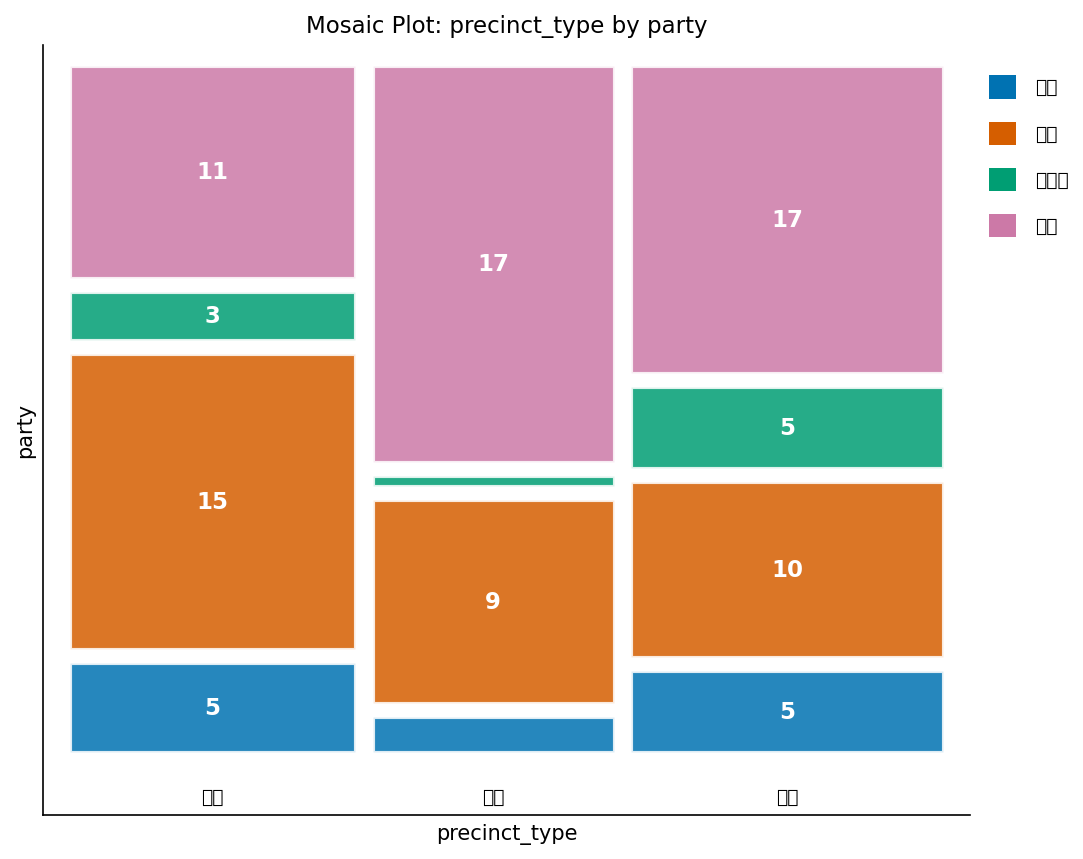

In [7]:
/* --------------------------------------------------------
   Export the precinct type x party summary for downstream
   redistricting impact assessment.
   -------------------------------------------------------- */
过程 频率 数据=work.precinct_votes;
    TABLES precinct_type * party / out=work.voting_pattern_summary nocum;
    标签 precinct_type = '选区类型' party = '党派';
运行;

过程 EXPORT 数据=work.voting_pattern_summary
    OUTFILE='precinct_voting_patterns.csv'
    DBMS=csv REPLACE;
运行;

---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; 机密
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
技术支持 <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>